In [3]:
import pandas as pd
df = pd.read_csv("jeruk_balance_500.csv")
df

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,7.75,216.4,0.51,11.1,Kalimantan,oranye,kemarau,Bagus
1,7.43,237.9,0.43,10.6,Jawa Tengah,kuning,kemarau,Bagus
2,7.82,195.1,0.60,12.9,Jawa Barat,oranye,hujan,Bagus
3,8.26,184.9,0.49,13.9,Kalimantan,oranye,hujan,Bagus
4,7.38,182.2,0.42,10.6,Jawa Barat,oranye,kemarau,Bagus
...,...,...,...,...,...,...,...,...
495,6.06,106.0,0.73,7.7,Jawa Tengah,hijau,kemarau,Jelek
496,5.50,108.8,0.92,10.4,Jawa Barat,hijau,kemarau,Jelek
497,5.50,95.5,1.05,8.4,Jawa Barat,hijau,hujan,Jelek
498,7.69,221.8,0.70,13.0,Jawa Barat,oranye,hujan,Bagus


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diameter     500 non-null    float64
 1   berat        500 non-null    float64
 2   tebal_kulit  500 non-null    float64
 3   kadar_gula   500 non-null    float64
 4   asal_daerah  500 non-null    str    
 5   warna        500 non-null    str    
 6   musim_panen  500 non-null    str    
 7   kualitas     500 non-null    str    
dtypes: float64(4), str(4)
memory usage: 44.7 KB


In [5]:
df.describe

<bound method NDFrame.describe of      diameter  berat  tebal_kulit  kadar_gula  asal_daerah   warna  \
0        7.75  216.4         0.51        11.1   Kalimantan  oranye   
1        7.43  237.9         0.43        10.6  Jawa Tengah  kuning   
2        7.82  195.1         0.60        12.9   Jawa Barat  oranye   
3        8.26  184.9         0.49        13.9   Kalimantan  oranye   
4        7.38  182.2         0.42        10.6   Jawa Barat  oranye   
..        ...    ...          ...         ...          ...     ...   
495      6.06  106.0         0.73         7.7  Jawa Tengah   hijau   
496      5.50  108.8         0.92        10.4   Jawa Barat   hijau   
497      5.50   95.5         1.05         8.4   Jawa Barat   hijau   
498      7.69  221.8         0.70        13.0   Jawa Barat  oranye   
499      7.57  200.5         0.46        13.6   Kalimantan  oranye   

    musim_panen kualitas  
0       kemarau    Bagus  
1       kemarau    Bagus  
2         hujan    Bagus  
3         hujan  

In [22]:
import matplotlib.pyplot as plt
bagus = df[df["kualitas"] == "Bagus"]
sedang = df[df["kualitas"] == "Sedang"]
jelek = df[df["kualitas"] == "Jelek"]


In [8]:
df["kualitas"].value_counts()

kualitas
Bagus     168
Sedang    166
Jelek     166
Name: count, dtype: int64

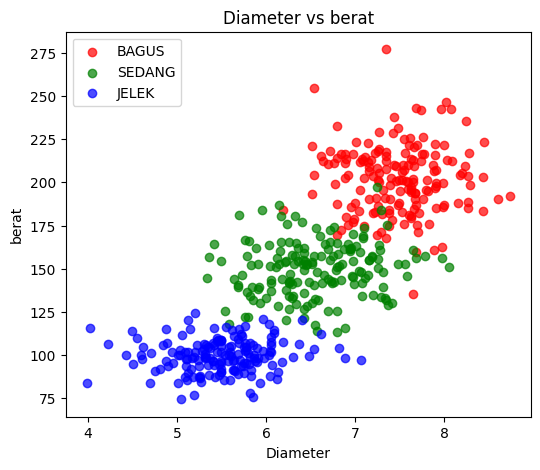

In [31]:
plt.figure(figsize=(6,5))
plt.scatter(bagus["diameter"],bagus["berat"], alpha=0.7, color="red", label ="BAGUS")
plt.scatter(sedang["diameter"],sedang["berat"], alpha=0.7, color="green", label ="SEDANG")
plt.scatter(jelek["diameter"],jelek["berat"], alpha=0.7, color="blue", label ="JELEK")
plt.xlabel("Diameter")
plt.ylabel("berat")
plt.title("Diameter vs berat")
plt.legend()

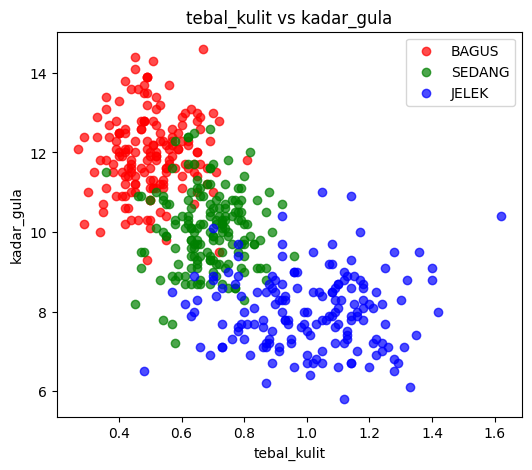

In [32]:
plt.figure(figsize=(6,5))
plt.scatter(bagus["tebal_kulit"],bagus["kadar_gula"], alpha=0.7, color="red", label ="BAGUS")
plt.scatter(sedang["tebal_kulit"],sedang["kadar_gula"], alpha=0.7, color="green", label ="SEDANG")
plt.scatter(jelek["tebal_kulit"],jelek["kadar_gula"], alpha=0.7, color="blue", label ="JELEK")
plt.xlabel("tebal_kulit")
plt.ylabel("kadar_gula")
plt.title("tebal_kulit vs kadar_gula")
plt.legend()

In [55]:
from sklearn.linear_model import LogisticRegression #buat algoritma modelnya
from sklearn.model_selection import train_test_split #buat ngesplit data (train dan test).
from sklearn.preprocessing import StandardScaler , OneHotEncoder, OrdinalEncoder #sclaer buat standarisasi, onehot buat ngubah data tulisan jadi angka, ordinal buat yang punya urutan(warna)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#1 Nentuin apa atribut yang dipake(X), dan apa targetnya(Y)
X = df[["diameter","berat","tebal_kulit", "kadar_gula","asal_daerah","warna", "musim_panen"]]
y = df["kualitas"] 

#2 split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

#3 atasi pembagian jenis atribut(numeric, ordinal, dll)
numeric_columns = ["diameter", "berat", "tebal_kulit", "kadar_gula"] #diproses oleh standard scaler
categorical_columns = ["asal_daerah", "musim_panen"] #dipreprosesing oleh OneHotEncoder

ordinal_columns = ["warna"] #dipreprosesing oleh ordinalencoder
warna_order = ["hijau", "kuning", "oranye"]
ordinal_order = [warna_order]

#4 Preprocessing
preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

#5 pipeline(buat otak kosong)
model = Pipeline(
    steps = [
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

#6 suruh otak belajar(train) 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nclassification_report: \n", classification_report(y_test, y_pred))

Accuracy:  0.99

classification_report: 
               precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        35
       Jelek       1.00      0.98      0.99        41
      Sedang       0.96      1.00      0.98        24

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [85]:
data_baru = pd.DataFrame([[10.89,0,0.35,10,"Kalimantan", "oranye", "kemarau"]],
                         columns=["diameter","berat","tebal_kulit", "kadar_gula","asal_daerah","warna", "musim_panen"])
hasil = model.predict(data_baru)[0]
prob = max(model.predict_proba(data_baru)[0])
print(f"hasil: {hasil} \nprob: {prob*100:.2f} %")

hasil: Sedang 
prob: 91.88 %


In [86]:
import joblib
joblib.dump(model, "model_klasifikasi_jeruk.joblib")

['model_klasifikasi_jeruk.joblib']

In [78]:
x = max(df["kadar_gula"])
print(x)

14.6


In [81]:
df["asal_daerah"].value_counts()

asal_daerah
Jawa Tengah    194
Kalimantan     163
Jawa Barat     143
Name: count, dtype: int64

In [83]:
df["warna"].value_counts()

warna
hijau     255
kuning    148
oranye     97
Name: count, dtype: int64

In [84]:
df["musim_panen"].value_counts()

musim_panen
kemarau    251
hujan      249
Name: count, dtype: int64